## Análisis de errores y feature importance

# Imports y lineas obligatorias

In [2]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

df = pd.read_csv("../data/processed/telco_engineered.csv")

model = joblib.load("../models/final_model.pkl")

X = df.drop(columns=["Churn"])
y = df["Churn"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

y_proba = model.predict_proba(X_test)[:, 1]

threshold = threshold = joblib.load("../models/threshold.pkl")

y_pred = (y_proba >= threshold).astype(int)

# Matriz de confusión

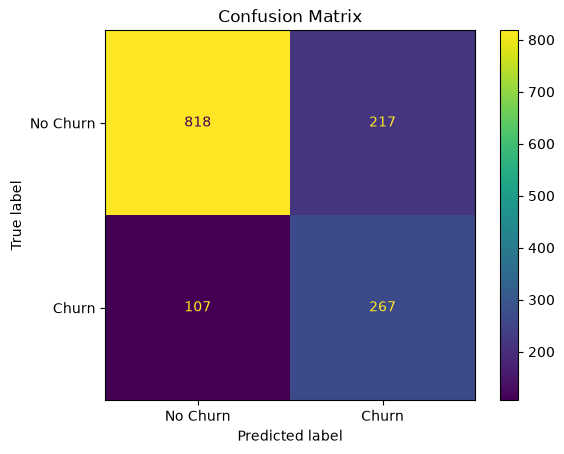

In [3]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [4]:
analysis_df = X_test.copy()

analysis_df["actual"] = y_test.values
analysis_df["probability"] = y_proba
analysis_df["prediction"] = y_pred


analysis_df["error_type"] = np.select(
    [
        (analysis_df["actual"] == 1) & (analysis_df["prediction"] == 1),
        (analysis_df["actual"] == 0) & (analysis_df["prediction"] == 0),
        (analysis_df["actual"] == 0) & (analysis_df["prediction"] == 1),
        (analysis_df["actual"] == 1) & (analysis_df["prediction"] == 0)
    ],
    [
        "True Positive", # El cliente desertó y el modelo lo predijo
        "True Negative", # El cliente no desertó y el modelo predijo lo mismo 
        "False Positive", # El cliente no desertó pero el modelo predijo que si lo hizo 
        "False Negative" # El cliente desertó pero el modelo predijo que hizo que no lo hizo
    ],
    default="Unknown"
)

In [5]:
analysis_df["error_type"].value_counts()

error_type
True Negative     818
True Positive     267
False Positive    217
False Negative    107
Name: count, dtype: int64

In [6]:
true_positives = analysis_df[
    analysis_df["error_type"] == "True Positive"
]

true_negatives = analysis_df[
    analysis_df["error_type"] == "True Negative"
]


false_positives = analysis_df[
    analysis_df["error_type"] == "False Positive"
]

false_negatives = analysis_df[
    analysis_df["error_type"] == "False Negative"
]

false_negatives.head()

,SeniorCitizen,Partner,Dependents,tenure,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,meanMonthlyCharge,actual,probability,prediction,error_type
2488,0,No,No,31,DSL,No,No,Yes,Yes,No,...,Month-to-month,Yes,Electronic check,55.25,1715.65,55.343548,1,0.385995,0,False Negative
523,0,No,No,23,Fiber optic,No,No,No,No,No,...,Month-to-month,No,Bank transfer (automatic),75.60,1758.60,76.460870,1,0.328868,0,False Negative
5086,0,No,No,45,No,No internet service,No internet service,No internet service,No internet service,No internet service,...,One year,Yes,Electronic check,20.40,930.45,20.676667,1,0.061819,0,False Negative
3408,0,No,No,4,DSL,No,Yes,No,No,No,...,Month-to-month,No,Credit card (automatic),50.70,151.30,37.825000,1,0.436932,0,False Negative
7011,0,No,No,4,DSL,Yes,Yes,No,Yes,No,...,Month-to-month,Yes,Mailed check,60.40,272.15,68.037500,1,0.265413,0,False Negative


In [7]:
false_negatives.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,meanMonthlyCharge,actual,probability,prediction
count,107.000000,107.000000,107.000000,107.000000,107.000000,107.0,107.000000,107.0
mean,0.196262,30.887850,69.641121,2605.409346,69.444131,1.0,0.288960,0.0
std,0.399038,21.604213,29.545925,2316.371377,29.914887,0.0,0.133875,0.0
min,0.000000,1.000000,18.950000,20.550000,14.150000,1.0,0.010310,0.0
25%,0.000000,11.000000,49.975000,485.800000,49.348611,1.0,0.194753,0.0
50%,0.000000,31.000000,70.150000,2088.750000,68.808333,1.0,0.295122,0.0
75%,0.000000,48.000000,95.775000,4013.075000,96.913120,1.0,0.405520,0.0
max,1.000000,72.000000,115.650000,7968.850000,115.529412,1.0,0.473841,0.0


In [8]:
false_negatives["Contract"].value_counts()

Contract
Month-to-month    65
One year          33
Two year           9
Name: count, dtype: int64

In [9]:
false_negatives["InternetService"].value_counts()

InternetService
Fiber optic    50
DSL            41
No             16
Name: count, dtype: int64

In [10]:
false_negatives["PaymentMethod"].value_counts()

PaymentMethod
Bank transfer (automatic)    32
Electronic check             27
Credit card (automatic)      24
Mailed check                 24
Name: count, dtype: int64

In [11]:
false_positives.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,meanMonthlyCharge,actual,probability,prediction
count,217.000000,217.000000,217.000000,217.000000,217.000000,217.0,217.000000,217.0
mean,0.235023,17.880184,74.147235,1587.614977,73.965574,0.0,0.647609,1.0
std,0.424994,18.372293,24.904895,1821.867997,25.197180,0.0,0.112353,0.0
min,0.000000,1.000000,19.400000,19.400000,19.400000,0.0,0.474781,1.0
25%,0.000000,3.000000,55.300000,190.250000,54.325000,0.0,0.553321,1.0
50%,0.000000,9.000000,79.150000,724.650000,79.534615,0.0,0.634488,1.0
75%,0.000000,29.000000,94.050000,2414.550000,93.025000,0.0,0.726601,1.0
max,1.000000,67.000000,114.100000,7132.150000,116.920492,0.0,0.898073,1.0


In [12]:
false_positives["Contract"].value_counts()

Contract
Month-to-month    207
One year           10
Name: count, dtype: int64

In [13]:
false_positives["InternetService"].value_counts()

InternetService
Fiber optic    153
DSL             49
No              15
Name: count, dtype: int64

In [14]:
false_positives["PaymentMethod"].value_counts()

PaymentMethod
Electronic check             134
Mailed check                  45
Credit card (automatic)       25
Bank transfer (automatic)     13
Name: count, dtype: int64

In [15]:
pd.crosstab(
    analysis_df["Contract"],
    analysis_df["error_type"],
    normalize="index"
)

error_type,False Negative,False Positive,True Negative,True Positive
Contract,,,,
Month-to-month,0.084088,0.267788,0.306598,0.341527
One year,0.110000,0.033333,0.846667,0.010000
Two year,0.026786,0.000000,0.973214,0.000000


In [16]:
pd.crosstab(
    analysis_df["InternetService"],
    analysis_df["error_type"],
    normalize="index"
)

error_type,False Negative,False Positive,True Negative,True Positive
InternetService,,,,
DSL,0.084711,0.101240,0.698347,0.115702
Fiber optic,0.081566,0.249592,0.339315,0.329527
No,0.051282,0.048077,0.871795,0.028846


In [17]:
pd.crosstab(
    analysis_df["PaymentMethod"],
    analysis_df["error_type"],
    normalize="index"
)

error_type,False Negative,False Positive,True Negative,True Positive
PaymentMethod,,,,
Bank transfer (automatic),0.106667,0.043333,0.766667,0.083333
Credit card (automatic),0.077670,0.080906,0.754045,0.087379
Electronic check,0.056962,0.282700,0.282700,0.377637
Mailed check,0.073620,0.138037,0.677914,0.110429


In [18]:
pd.crosstab(
    analysis_df["TechSupport"],
    analysis_df["error_type"],
    normalize="index"
)

error_type,False Negative,False Positive,True Negative,True Positive
TechSupport,,,,
No,0.074074,0.235043,0.353276,0.337607
No internet service,0.051282,0.048077,0.871795,0.028846
Yes,0.098734,0.093671,0.754430,0.053165


In [19]:
pd.crosstab(
    analysis_df["OnlineBackup"],
    analysis_df["error_type"],
    normalize="index"
)

error_type,False Negative,False Positive,True Negative,True Positive
OnlineBackup,,,,
No,0.082043,0.227554,0.380805,0.309598
No internet service,0.051282,0.048077,0.871795,0.028846
Yes,0.084257,0.121951,0.665188,0.128603


In [20]:
pd.crosstab(
    analysis_df["DeviceProtection"],
    analysis_df["error_type"],
    normalize="index"
)

error_type,False Negative,False Positive,True Negative,True Positive
DeviceProtection,,,,
No,0.089888,0.239165,0.362761,0.308186
No internet service,0.051282,0.048077,0.871795,0.028846
Yes,0.073840,0.111814,0.675105,0.139241


# Feature Importance del mejor modelo

In [21]:
model.named_steps

{'pre_smote': ColumnTransformer(transformers=[('num',
                                  Pipeline(steps=[('imputer',
                                                   SimpleImputer(strategy='median')),
                                                  ('scaler', MinMaxScaler())]),
                                  ['tenure', 'meanMonthlyCharge',
                                   'MonthlyCharges', 'TotalCharges']),
                                 ('cat', SimpleImputer(strategy='most_frequent'),
                                  ['SeniorCitizen', 'Partner', 'Dependents',
                                   'InternetService', 'OnlineSecurity',
                                   'OnlineBackup', 'DeviceProtection',
                                   'TechSupport', 'StreamingTV',
                                   'StreamingMovies', 'Contract',
                                   'PaperlessBilling', 'PaymentMethod'])]),
 'smotenc': SMOTENC(categorical_features=[4, 5, 6, 7, 8, 9, 10, 11, 12, 

In [22]:
classifier = model.named_steps["classifier"]

In [23]:
classifier.feature_importances_

array([0.00442394, 0.00681409, 0.01326175, 0.01187439, 0.08243632,
       0.        , 0.08338826, 0.        , 0.00670429, 0.01781982,
       0.        , 0.00558191, 0.00302398, 0.        , 0.01145259,
       0.06518211, 0.        , 0.0072445 , 0.01405389, 0.        ,
       0.00591813, 0.00491683, 0.        , 0.02947908, 0.43736193,
       0.03005753, 0.02142984, 0.01782728, 0.00505957, 0.0077026 ,
       0.04927203, 0.00620484, 0.02110812, 0.00748282, 0.01425839,
       0.00865924], dtype=float32)

In [24]:
preprocessor = model.named_steps["post_smote"]

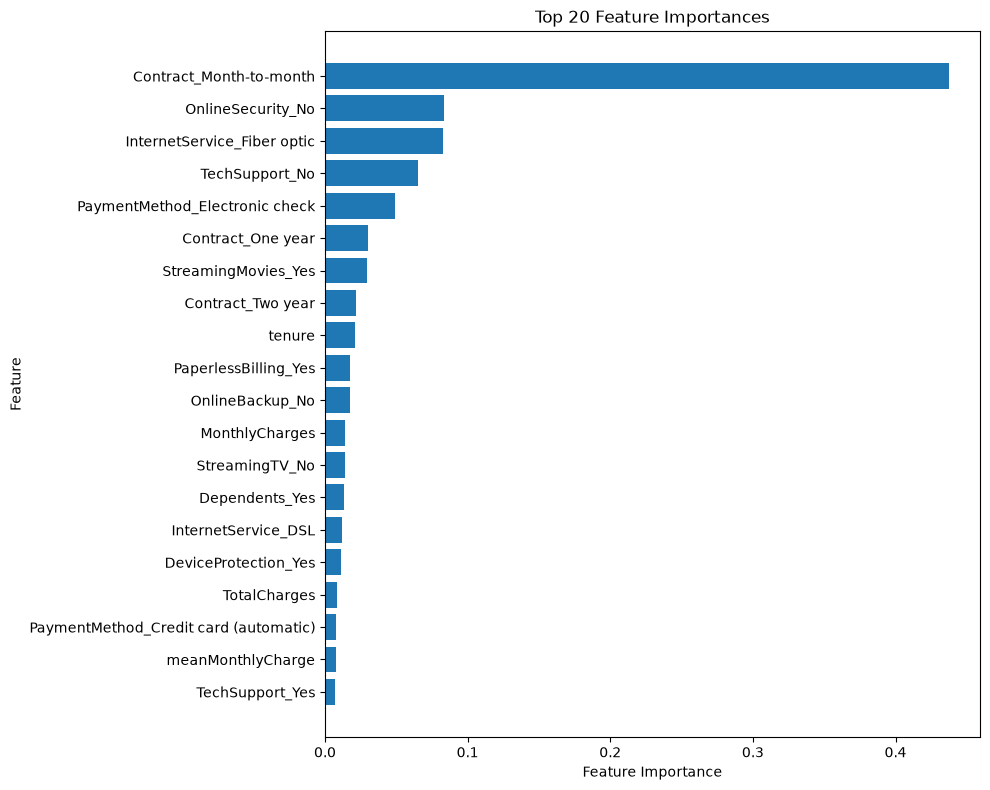

In [25]:

preprocessor = model.named_steps["post_smote"]
feature_names = preprocessor.get_feature_names_out()
importances = model.named_steps["classifier"].feature_importances_

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})


# 1. Eliminar solo el prefijo del transformador (elimina 'ohe__' y 'remainder__')
# Esto dejará los nombres como: 'x14_Month-to-month', 'x8_No', 'x0', etc.
feature_importance["feature"] = feature_importance["feature"].str.replace(r'^.*?__', '', regex=True)

# 2. Mapear los índices 'xN' a los nombres reales de tus columnas.
nombres_reales = {
    "x0": "tenure",
    "x1": "meanMonthlyCharge",
    "x2": "MonthlyCharges", 
    "x3": "TotalCharges",
    "x4": "Senior Citizen",
    "x5": "Partner",
    "x6": "Dependents",
    "x7": "InternetService",
    "x8": "OnlineSecurity", 
    "x9": "OnlineBackup",  
    "x10": "DeviceProtection",
    "x11": "TechSupport",   
    "x12": "StreamingTV",  
    "x13": "StreamingMovies",
    "x14": "Contract",
    "x15": "PaperlessBilling",
    "x16": "PaymentMethod"
}

# Reemplazar 'xN_' por 'NombreColumna_'
for x_idx, real_name in nombres_reales.items():
    # Caso A: Variables categóricas (ej. 'x14_Month-to-month' -> 'Contract_Month-to-month')
    feature_importance["feature"] = feature_importance["feature"].str.replace(
        rf'^{x_idx}_', f'{real_name}_', regex=True
    )
    # Caso B: Variables numéricas exactas (ej. 'x0' -> 'tenure')
    feature_importance["feature"] = feature_importance["feature"].str.replace(
        rf'^{x_idx}$', real_name, regex=True
    )


feature_importance = (
    feature_importance
    .sort_values("importance", ascending=False)
    .head(20)
    .sort_values("importance")
)

plt.figure(figsize=(10, 8))

plt.barh(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 20 Feature Importances")

plt.tight_layout()
plt.show()
